In [10]:
from convokit import Corpus, download
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# %pip install wordcloud
from wordcloud import WordCloud
from collections import defaultdict
import re


import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

In [ ]:
# --- Install dependencies (uncomment the pip lines if needed) ---
# %pip install convokit networkx nltk pandas matplotlib


# Make sure nltk resources are available
nltk.download('vader_lexicon')

# -------- CONFIG --------
SUBREDDIT_NAME = "Cornell"  # <- change this to any subreddit you want
DATASET_ID = f"subreddit-{SUBREDDIT_NAME}"  # convokit naming convention

# -------- LOAD CORPUS --------
corpus = Corpus(filename=download(DATASET_ID))
corpus.print_summary_stats()


[nltk_data] Downloading package vader_lexicon to C:\Users\Mikkel
[nltk_data]     Groengaard\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Dataset already exists at C:\Users\Mikkel Groengaard\.convokit\saved-corpora\subreddit-Cornell
Number of Speakers: 7568
Number of Utterances: 74467
Number of Conversations: 10744


In [3]:
import networkx as nx

def build_interaction_graph_safe(corpus):
    """
    Build a directed interaction graph between speakers:
    node  = speaker id (username)
    edge u -> v if u replies to v at least once
    weight = number of replies

    Any utterance whose parent is missing / inconsistent is safely skipped.
    """
    G = nx.DiGraph()

    for utt in corpus.iter_utterances():
        # Skip root posts / comments
        if utt.reply_to is None:
            continue

        # Robust parent lookup: skip if anything goes wrong
        try:
            parent_utt = corpus.get_utterance(utt.reply_to)
        except KeyError:
            # This is where your 'c3ooo7j' error comes from – parent missing
            continue

        if parent_utt is None:
            continue

        # Check speakers exist
        if utt.speaker is None or parent_utt.speaker is None:
            continue

        src = utt.speaker.id           # replier
        tgt = parent_utt.speaker.id    # person being replied to

        # Optional: skip self-replies
        if src == tgt:
            continue

        # Ensure nodes exist
        if src not in G:
            G.add_node(src)
        if tgt not in G:
            G.add_node(tgt)

        # Update weighted edge
        if G.has_edge(src, tgt):
            G[src][tgt]["weight"] += 1
        else:
            G.add_edge(src, tgt, weight=1)

    return G

G = build_interaction_graph_safe(corpus)
print("Number of nodes (speakers):", G.number_of_nodes())
print("Number of edges (reply-relations):", G.number_of_edges())


Number of nodes (speakers): 7235
Number of edges (reply-relations): 45496


In [4]:
# Check what attributes the Corpus actually has
print(type(corpus))
print([attr for attr in dir(corpus) if not attr.startswith("_")])

# Peek at a single utterance
some_utt = next(corpus.iter_utterances())
print("Utterance id:", some_utt.id)
print("Reply to:", some_utt.reply_to)
print("Speaker object:", some_utt.speaker)
print("Speaker id:", some_utt.speaker.id if some_utt.speaker else None)
print("Text:", some_utt.text[:200])

<class 'convokit.model.corpus.Corpus'>
['add_meta', 'add_utterances', 'append_vector_matrix', 'backend', 'backend_mapper', 'config', 'conversations', 'corpus_dirpath', 'delete_metadata', 'delete_vector_matrix', 'directed_pairwise_exchanges', 'dump', 'dump_info', 'dump_vectors', 'filter_conversations_by', 'filter_utterances', 'from_pandas', 'get_attribute_table', 'get_conversation', 'get_conversation_ids', 'get_conversations_dataframe', 'get_full_attribute_table', 'get_meta', 'get_object', 'get_object_ids', 'get_speaker', 'get_speaker_convo_attribute_table', 'get_speaker_convo_info', 'get_speaker_ids', 'get_speakers_dataframe', 'get_utterance', 'get_utterance_ids', 'get_utterances_dataframe', 'get_vector_matrix', 'get_vectors', 'has_conversation', 'has_speaker', 'has_utterance', 'id', 'iter_conversations', 'iter_objs', 'iter_speakers', 'iter_utterances', 'load_info', 'merge', 'meta', 'meta_index', 'organize_speaker_convo_history', 'print_summary_stats', 'random_conversation', 'random_sp

Nodes: 7235
Edges: 45496
Density: 0.000869
Number of weakly connected components: 12
Largest weakly connected component size: 7213
Number of strongly connected components: 2765
Largest strongly connected component size: 4440
Out degree: mean=6.288, median=1.000, max=2099, nonzero=6106
In degree: mean=6.288, median=2.000, max=1852, nonzero=5718


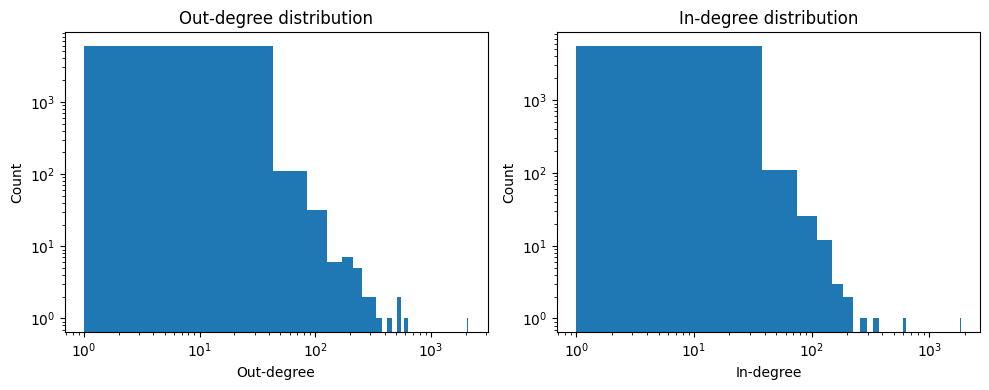

In [5]:
def summarize_network(G):
    n = G.number_of_nodes()
    m = G.number_of_edges()
    density = nx.density(G)

    print(f"Nodes: {n}")
    print(f"Edges: {m}")
    print(f"Density: {density:.6f}")

    # Weakly and strongly connected components
    if n > 0:
        weak_ccs = list(nx.weakly_connected_components(G))
        strong_ccs = list(nx.strongly_connected_components(G))

        largest_weak_cc = max(weak_ccs, key=len)
        largest_strong_cc = max(strong_ccs, key=len)

        print(f"Number of weakly connected components: {len(weak_ccs)}")
        print(f"Largest weakly connected component size: {len(largest_weak_cc)}")
        print(f"Number of strongly connected components: {len(strong_ccs)}")
        print(f"Largest strongly connected component size: {len(largest_strong_cc)}")

    # Degree distributions
    out_degrees = np.array([deg for _, deg in G.out_degree()])
    in_degrees  = np.array([deg for _, deg in G.in_degree()])

    def describe_degrees(name, degs):
        if len(degs) == 0:
            print(f"{name} degrees: (no nodes)")
            return
        print(f"{name} degree: mean={degs.mean():.3f}, "
              f"median={np.median(degs):.3f}, "
              f"max={degs.max()}, "
              f"nonzero={np.count_nonzero(degs)}")

    describe_degrees("Out", out_degrees)
    describe_degrees("In",  in_degrees)

    # Plot degree distributions (log-log)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].hist(out_degrees[out_degrees > 0], bins=50)
    axes[0].set_xscale('log')
    axes[0].set_yscale('log')
    axes[0].set_title("Out-degree distribution")
    axes[0].set_xlabel("Out-degree")
    axes[0].set_ylabel("Count")

    axes[1].hist(in_degrees[in_degrees > 0], bins=50)
    axes[1].set_xscale('log')
    axes[1].set_yscale('log')
    axes[1].set_title("In-degree distribution")
    axes[1].set_xlabel("In-degree")
    axes[1].set_ylabel("Count")

    plt.tight_layout()
    plt.show()

summarize_network(G)


In [6]:
def analyze_structure_and_centrality(G, sample_for_centrality=True, max_nodes=5000):
    # Undirected version for clustering / k-core / some community algorithms
    G_und = G.to_undirected()

    # Global clustering and average clustering
    if G_und.number_of_nodes() > 0:
        avg_clustering = nx.average_clustering(G_und)
        print(f"Average clustering coefficient (undirected): {avg_clustering:.4f}")

    # Degree assortativity (on undirected graph)
    try:
        assortativity = nx.degree_assortativity_coefficient(G_und)
        print(f"Degree assortativity coefficient: {assortativity:.4f}")
    except Exception as e:
        print("Could not compute assortativity:", e)

    # k-core analysis
    try:
        core_numbers = nx.core_number(G_und)
        max_core = max(core_numbers.values())
        print(f"Max k-core index: {max_core}")
    except Exception as e:
        print("Could not compute core numbers (graph may be too big or disconnected):", e)
        core_numbers = {}

    # Work with largest weakly connected component for centrality
    if G.number_of_nodes() == 0:
        print("Empty graph; skipping centrality.")
        return None

    largest_weak_cc = max(nx.weakly_connected_components(G), key=len)
    G_lcc = G.subgraph(largest_weak_cc).copy()
    print("LCC size:", G_lcc.number_of_nodes(), "nodes,", G_lcc.number_of_edges(), "edges")

    # Optionally downsample if graph is huge
    if sample_for_centrality and G_lcc.number_of_nodes() > max_nodes:
        sampled_nodes = np.random.choice(list(G_lcc.nodes()), size=max_nodes, replace=False)
        G_lcc = G_lcc.subgraph(sampled_nodes).copy()
        print("Downsampled centrality graph to", G_lcc.number_of_nodes(), "nodes")

    # Degree centralities
    in_deg_cent  = dict(G_lcc.in_degree())
    out_deg_cent = dict(G_lcc.out_degree())

    # Normalize degree centralities
    n_lcc = G_lcc.number_of_nodes()
    in_deg_cent_norm  = {n: d / (n_lcc - 1) for n, d in in_deg_cent.items()}
    out_deg_cent_norm = {n: d / (n_lcc - 1) for n, d in out_deg_cent.items()}

    # Betweenness centrality (approx): HERE IS THE FIX
    print("Computing betweenness centrality (approx)...")
    k_sample = min(500, n_lcc)  # number of nodes to sample
    betw_cent = nx.betweenness_centrality(
        G_lcc,
        k=k_sample,          # integer, not array
        normalized=True,
        seed=42
    )

    # PageRank
    print("Computing PageRank...")
    pagerank = nx.pagerank(G_lcc, alpha=0.85)

    # Put everything into a DataFrame
    df_cent = pd.DataFrame({
        "in_degree": pd.Series(in_deg_cent),
        "out_degree": pd.Series(out_deg_cent),
        "in_deg_centrality": pd.Series(in_deg_cent_norm),
        "out_deg_centrality": pd.Series(out_deg_cent_norm),
        "betweenness": pd.Series(betw_cent),
        "pagerank": pd.Series(pagerank),
    })

    # Optionally include core number if computed
    if core_numbers:
        df_cent["core_number"] = df_cent.index.map(core_numbers).fillna(0).astype(int)

    print(df_cent.sort_values("pagerank", ascending=False).head(10))
    return df_cent


In [7]:
df_cent = analyze_structure_and_centrality(G)

Average clustering coefficient (undirected): 0.1980
Degree assortativity coefficient: -0.0883
Max k-core index: 24
LCC size: 7213 nodes, 45483 edges
Downsampled centrality graph to 5000 nodes
Computing betweenness centrality (approx)...
Computing PageRank...
                    in_degree  out_degree  in_deg_centrality  \
laveritecestla            423         425           0.084617   
t3hasiangod               194         308           0.038808   
omgdonerkebab             139         234           0.027806   
SwissWatchesOnly          149          70           0.029806   
CornHellUniversity        105         341           0.021004   
cartesiancategory          92         199           0.018404   
cornell256                 82         190           0.016403   
SpookBusters               80         142           0.016003   
TheD3xus                   73          76           0.014603   
Billaboong                 92          44           0.018404   

                    out_deg_centrali

Undirected graph - Nodes: 7235 Edges: 36304
Average degree: 10.0356599861783


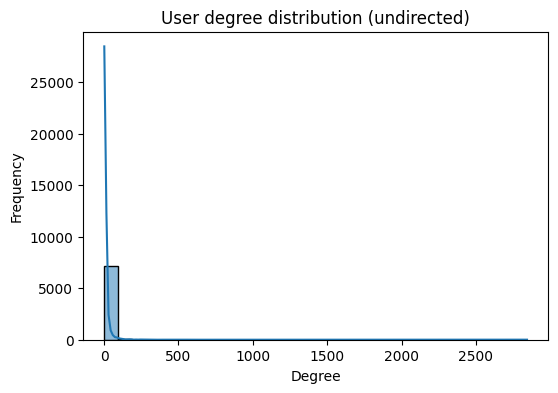

Top 5 by degree centrality:
  [deleted]: 2844.0000
  laveritecestla: 905.0000
  EQUASHNZRKUL: 656.0000
  CornHellUniversity: 549.0000
  t3hasiangod: 515.0000

Top 5 by betweenness centrality:
  [deleted]: 0.5636
  laveritecestla: 0.0966
  EQUASHNZRKUL: 0.0428
  t3hasiangod: 0.0390
  CornHellUniversity: 0.0316

Top 5 by closeness centrality:
  [deleted]: 0.5975
  laveritecestla: 0.4706
  EQUASHNZRKUL: 0.4602
  omgdonerkebab: 0.4475
  CornHellUniversity: 0.4471

Top 5 by eigenvector centrality:
  [deleted]: 0.4395
  laveritecestla: 0.1725
  EQUASHNZRKUL: 0.1723
  CornHellUniversity: 0.1352
  ilovemymemesboo: 0.1153

Degree assortativity (undirected): -0.08832241808240408
MST backbone - nodes: 7235 edges: 7223


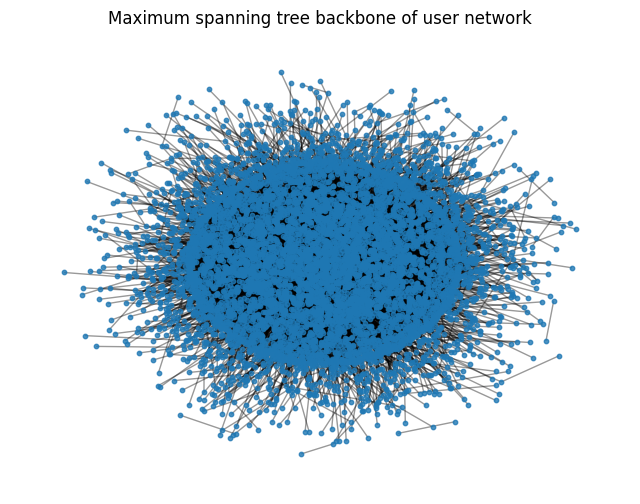

In [8]:
import seaborn as sns
from collections import Counter

# Undirected version for these analyses
G_und = G.to_undirected()

print("Undirected graph - Nodes:", G_und.number_of_nodes(), "Edges:", G_und.number_of_edges())

# --- Average degree and degree distribution (like in the rock notebook) ---
avg_degree = sum(dict(G_und.degree()).values()) / G_und.number_of_nodes()
print("Average degree:", avg_degree)

degrees = [d for _, d in G_und.degree()]
plt.figure(figsize=(6,4))
sns.histplot(degrees, bins=30, kde=True)
plt.title("User degree distribution (undirected)")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.show()

# --- Centrality measures (global, undirected) ---
deg_c = dict(G_und.degree())
bet_c = nx.betweenness_centrality(G_und)
clo_c = nx.closeness_centrality(G_und)
eig_c = nx.eigenvector_centrality(G_und, max_iter=500)

def print_top5(centrality, name):
    top5 = sorted(centrality.items(), key=lambda x: x[1], reverse=True)[:5]
    print(f"Top 5 by {name} centrality:")
    for u, v in top5:
        print(f"  {u}: {v:.4f}")
    print()

print_top5(deg_c, "degree")
print_top5(bet_c, "betweenness")
print_top5(clo_c, "closeness")
print_top5(eig_c, "eigenvector")

# --- Degree assortativity (already similar but this is global) ---
assort = nx.degree_assortativity_coefficient(G_und)
print("Degree assortativity (undirected):", assort)

# --- Maximum Spanning Tree backbone (similar idea to notebook MST) ---
wG = G_und.copy()
for u, v, d in wG.edges(data=True):
    # use reply count as weight if present, otherwise 1
    d["weight"] = float(d.get("weight", 1.0))

mst = nx.maximum_spanning_tree(wG, weight="weight")
print("MST backbone - nodes:", mst.number_of_nodes(), "edges:", mst.number_of_edges())

# Optional: quick visualization of MST backbone
plt.figure(figsize=(8,6))
pos_mst = nx.spring_layout(mst, seed=42, k=0.15)
nx.draw_networkx_edges(mst, pos_mst, alpha=0.4)
nx.draw_networkx_nodes(mst, pos_mst, node_size=10, alpha=0.8)
plt.title("Maximum spanning tree backbone of user network")
plt.axis("off")
plt.show()


In [9]:
# Giant connected component on the undirected graph
gcc_nodes = max(nx.connected_components(G_und), key=len)
Gcc = G_und.subgraph(gcc_nodes).copy()
print("GCC size:", Gcc.number_of_nodes(), "nodes,", Gcc.number_of_edges(), "edges")

avg_path_len = nx.average_shortest_path_length(Gcc)
ecc = nx.eccentricity(Gcc)
diameter = max(ecc.values())

print(f"Average shortest path length in GCC: {avg_path_len:.3f}")
print(f"Diameter of GCC: {diameter}")


GCC size: 7213 nodes, 36293 edges
Average shortest path length in GCC: 3.123
Diameter of GCC: 12


In [11]:
from networkx.algorithms.community import louvain_communities

def detect_communities(G, max_nodes=20000):
    # Work on undirected version of the largest connected component
    G_und = G.to_undirected()
    largest_cc = max(nx.connected_components(G_und), key=len)
    H = G_und.subgraph(largest_cc).copy()

    if H.number_of_nodes() > max_nodes:
        sampled_nodes = np.random.choice(list(H.nodes()), size=max_nodes, replace=False)
        H = H.subgraph(sampled_nodes).copy()
        print("Downsampled community graph to", H.number_of_nodes(), "nodes")

    print("Running Louvain community detection...")
    communities = louvain_communities(H, seed=42)
    print(f"Detected {len(communities)} communities.")

    # Map node -> community id
    node2comm = {}
    for cid, comm in enumerate(communities):
        for node in comm:
            node2comm[node] = cid

    return node2comm

# Example usage:
node2comm = detect_communities(G)
df_cent["community"] = df_cent.index.map(node2comm)


Running Louvain community detection...
Detected 34 communities.


In [12]:
from networkx.algorithms.community import louvain_communities

# Louvain on the undirected graph
communities = list(louvain_communities(G_und, seed=42))
print("Detected communities (sizes):", [len(c) for c in communities])

mod_val = nx.community.modularity(G_und, communities)
print("Modularity:", mod_val)

# Map node -> community id
node2comm = {node: cid for cid, comm in enumerate(communities) for node in comm}


Detected communities (sizes): [2, 2, 3, 2, 2, 1956, 2, 3, 4, 71, 8, 361, 2, 9, 79, 2, 2, 5, 2, 2, 2, 2, 128, 268, 2, 2, 1916, 1730, 4, 2, 2, 3, 591, 4, 4, 2, 6, 7, 3, 2, 3, 2, 2, 2, 2, 4, 3, 2, 4, 2, 3, 2, 2, 3]
Modularity: 0.3517860124545781


C:\Users\Mikkel Groengaard\AppData\Local\Temp\ipykernel_27908\3998438590.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis", len(communities))


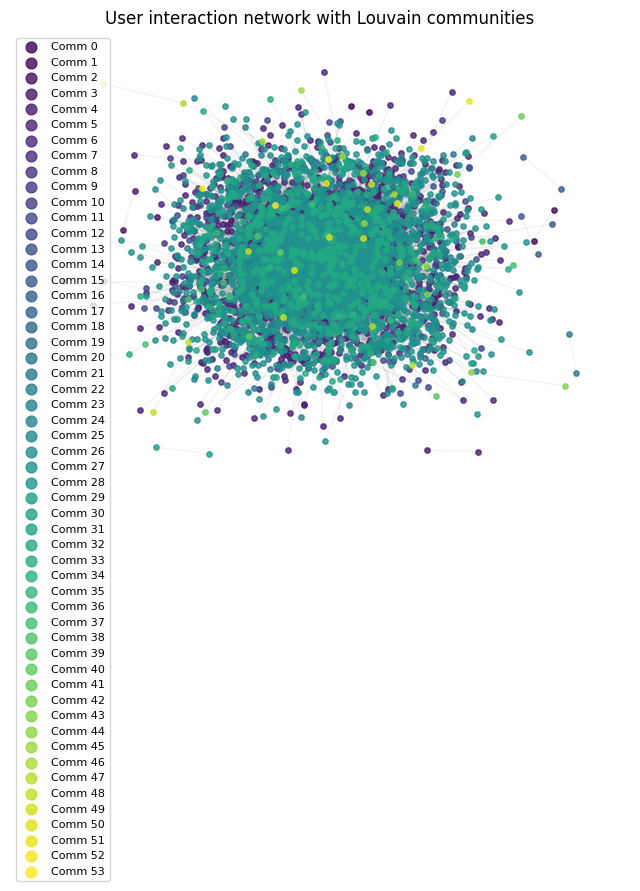

In [15]:
import matplotlib.cm as cm

plt.figure(figsize=(8,6))
pos = nx.spring_layout(G_und, seed=42)
cmap = cm.get_cmap("viridis", len(communities))

for i, community in enumerate(communities):
    nx.draw_networkx_nodes(
        G_und, pos,
        nodelist=list(community),
        node_color=[cmap(i)],
        node_size=15,
        alpha=0.8,
        label=f"Comm {i}"
    )

nx.draw_networkx_edges(G_und, pos, alpha=0.05)
plt.title("User interaction network with Louvain communities")
plt.axis("off")
plt.legend(markerscale=2, fontsize=8)
plt.show()


It is especially these communities that are interesting to analyze!

In [14]:
# Initialize VADER
sia = SentimentIntensityAnalyzer()

def compute_utterance_sentiments(corpus):
    records = []
    for utt_id, utt in corpus.utterances.items():
        text = utt.text or ""
        if not text.strip():
            continue

        scores = sia.polarity_scores(text)
        records.append({
            "utt_id": utt_id,
            "speaker": utt.speaker.id if utt.speaker else None,
            "conversation_id": utt.conversation_id,
            "compound": scores["compound"],
            "neg": scores["neg"],
            "neu": scores["neu"],
            "pos": scores["pos"],
        })

    df_sent = pd.DataFrame(records)
    return df_sent

df_sent = compute_utterance_sentiments(corpus)
df_sent.head()


,utt_id,speaker,conversation_id,compound,neg,neu,pos
0,nyx4d,reddmau5,nyx4d,0.8205,0.000,0.731,0.269
1,o0145,shtylman,o0145,0.9840,0.042,0.640,0.318
2,o1gca,moon_river,o1gca,0.5992,0.000,0.909,0.091
3,o0ss4,moon_river,o0ss4,0.4455,0.150,0.649,0.202
4,o4ipd,reddmau5,o4ipd,0.3400,0.091,0.792,0.117


In [16]:
# Sentiment per speaker (mean of their utterances)
speaker_sent = df_sent.groupby("speaker")["compound"].agg(
    mean_compound="mean",
    median_compound="median",
    count="size"
).reset_index()

# Sentiment per conversation
conv_sent = df_sent.groupby("conversation_id")["compound"].agg(
    mean_compound="mean",
    median_compound="median",
    count="size"
).reset_index()

print("Top speakers by number of utterances with sentiment scores:")
print(speaker_sent.sort_values("count", ascending=False).head(10))

print("\nMost positive conversations (mean compound):")
print(conv_sent[conv_sent["count"] >= 5].sort_values("mean_compound", ascending=False).head(10))

print("\nMost negative conversations (mean compound):")
print(conv_sent[conv_sent["count"] >= 5].sort_values("mean_compound").head(10))


Top speakers by number of utterances with sentiment scores:
                 speaker  mean_compound  median_compound  count
2659           [deleted]       0.054210          0.00000   8055
5013      laveritecestla       0.223652          0.10270   1172
839         EQUASHNZRKUL       0.176469          0.07720   1004
6529         t3hasiangod       0.312530          0.36460    942
607   CornHellUniversity       0.131350          0.00000    792
3316   cartesiancategory       0.411133          0.50580    592
4580     ilovemymemesboo       0.101134          0.00000    559
5615       omgdonerkebab       0.212301          0.12800    555
3507          cornell256       0.504505          0.72270    440
945           Fencerman2       0.452677          0.58335    370

Most positive conversations (mean compound):
     conversation_id  mean_compound  median_compound  count
8260          97cf57       0.951922          0.96220      9
1182          39nhhn       0.941337          0.96130      8
278       

In [17]:
# Make sure we have speaker-level sentiment from earlier
# speaker_sent: columns ['speaker', 'mean_compound', 'median_compound', 'count']

speaker_mean_sent = dict(zip(speaker_sent["speaker"], speaker_sent["mean_compound"]))

comm_sentiment = []
for cid, comm in enumerate(communities):
    vals = [speaker_mean_sent[u] for u in comm if u in speaker_mean_sent]
    mean_val = np.mean(vals) if vals else 0.0
    comm_sentiment.append((cid, mean_val, len(vals)))

for cid, mean_val, n_users in comm_sentiment:
    print(f"Community {cid}: mean sentiment = {mean_val:.3f} (users with sentiment: {n_users})")


Community 0: mean sentiment = -0.188 (users with sentiment: 1)
Community 1: mean sentiment = 0.696 (users with sentiment: 2)
Community 2: mean sentiment = 0.070 (users with sentiment: 3)
Community 3: mean sentiment = 0.153 (users with sentiment: 1)
Community 4: mean sentiment = 0.440 (users with sentiment: 1)
Community 5: mean sentiment = 0.337 (users with sentiment: 1900)
Community 6: mean sentiment = 0.120 (users with sentiment: 2)
Community 7: mean sentiment = 0.547 (users with sentiment: 3)
Community 8: mean sentiment = 0.564 (users with sentiment: 4)
Community 9: mean sentiment = 0.342 (users with sentiment: 69)
Community 10: mean sentiment = 0.521 (users with sentiment: 8)
Community 11: mean sentiment = 0.242 (users with sentiment: 356)
Community 12: mean sentiment = 0.554 (users with sentiment: 2)
Community 13: mean sentiment = 0.534 (users with sentiment: 9)
Community 14: mean sentiment = 0.359 (users with sentiment: 77)
Community 15: mean sentiment = 0.853 (users with sentimen

C:\Users\Mikkel Groengaard\AppData\Local\Temp\ipykernel_27908\204449754.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comm_indices, y=comm_values, palette="viridis")


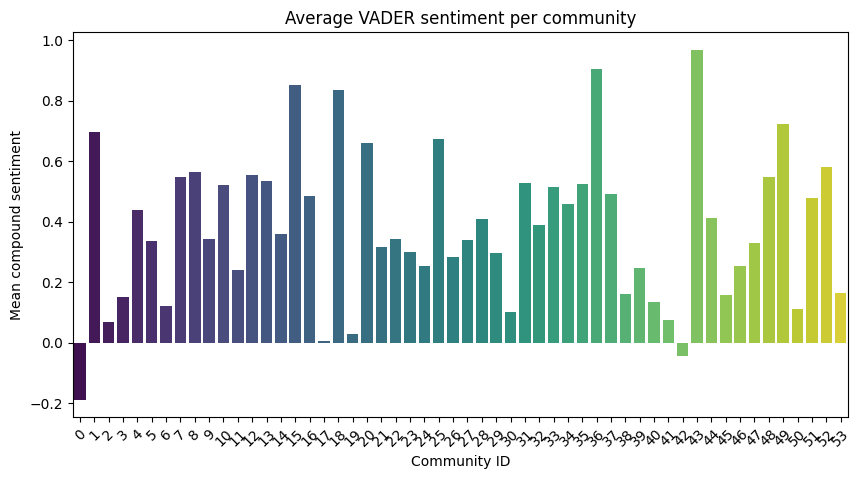

In [18]:
comm_indices = [cid for cid, _, _ in comm_sentiment]
comm_values  = [mean for _, mean, _ in comm_sentiment]

plt.figure(figsize=(10,5))
sns.barplot(x=comm_indices, y=comm_values, palette="viridis")
plt.title("Average VADER sentiment per community")
plt.xlabel("Community ID")
plt.ylabel("Mean compound sentiment")
plt.xticks(rotation=45)
plt.show()

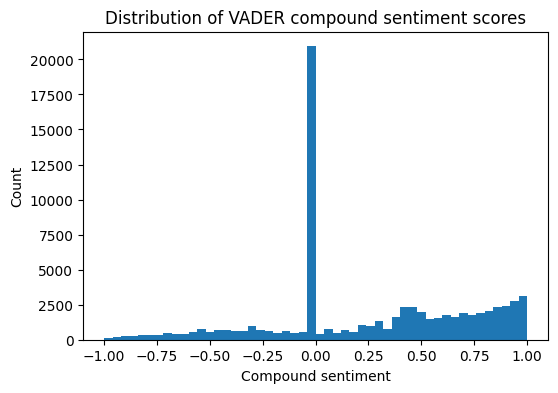

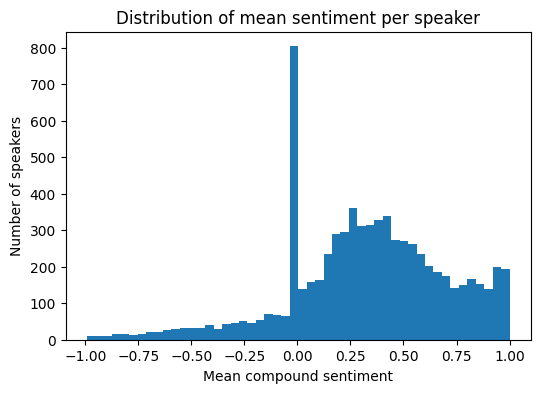

In [19]:
plt.figure(figsize=(6,4))
plt.hist(df_sent["compound"], bins=50)
plt.title("Distribution of VADER compound sentiment scores")
plt.xlabel("Compound sentiment")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(speaker_sent["mean_compound"], bins=50)
plt.title("Distribution of mean sentiment per speaker")
plt.xlabel("Mean compound sentiment")
plt.ylabel("Number of speakers")
plt.show()

In [20]:
# Join centrality metrics with speaker sentiments
df_cent = df_cent.copy()
df_cent.index.name = "speaker"
df_cent.reset_index(inplace=True)

df_speaker = pd.merge(
    df_cent,
    speaker_sent,
    on="speaker",
    how="left"
)

df_speaker.head()


,speaker,in_degree,out_degree,in_deg_centrality,out_deg_centrality,betweenness,pagerank,core_number,community,mean_compound,median_compound,count
0,throwaway543210,1,1,0.0002,0.0002,0.0,0.000170,3,0,0.470033,0.57750,6.0
1,newt22,1,2,0.0002,0.0004,0.0,0.000199,3,0,0.488200,0.59450,3.0
2,deadlykeyboard,0,2,0.0000,0.0004,0.0,0.000055,3,0,0.388850,0.38885,2.0
3,redderritter,2,2,0.0004,0.0004,0.0,0.000197,3,0,0.083333,0.00000,3.0
4,caela_ielle,0,2,0.0000,0.0004,0.0,0.000055,3,0,0.288733,0.31820,3.0


In [21]:
for cid, comm in enumerate(communities):
    comm_users = [(u, speaker_mean_sent.get(u, np.nan)) for u in comm if u in speaker_mean_sent]
    if not comm_users:
        continue

    comm_users = [p for p in comm_users if not np.isnan(p[1])]
    if not comm_users:
        continue

    top5 = sorted(comm_users, key=lambda x: x[1], reverse=True)[:5]
    bottom5 = sorted(comm_users, key=lambda x: x[1])[:5]

    print(f"\nCommunity {cid}:")
    print("  Top 5 users (most positive):")
    for u, s in top5:
        print(f"    {u}: {s:.3f}")
    print("  Bottom 5 users (most negative):")
    for u, s in bottom5:
        print(f"    {u}: {s:.3f}")


Community 0:
  Top 5 users (most positive):
    drboda: -0.188
  Bottom 5 users (most negative):
    drboda: -0.188

Community 1:
  Top 5 users (most positive):
    mayquite: 0.754
    looksuperman: 0.637
  Bottom 5 users (most negative):
    looksuperman: 0.637
    mayquite: 0.754

Community 2:
  Top 5 users (most positive):
    Nakedgrappler: 0.364
    UnoriginalNickname: 0.044
    MeSoCorny: -0.197
  Bottom 5 users (most negative):
    MeSoCorny: -0.197
    UnoriginalNickname: 0.044
    Nakedgrappler: 0.364

Community 3:
  Top 5 users (most positive):
    m8rd85: 0.153
  Bottom 5 users (most negative):
    m8rd85: 0.153

Community 4:
  Top 5 users (most positive):
    elmosfire12: 0.440
  Bottom 5 users (most negative):
    elmosfire12: 0.440

Community 5:
  Top 5 users (most positive):
    phdtrek: 1.000
    iamacoolpotato: 0.999
    heroesofmittens: 0.999
    danger0s: 0.998
    rotajota: 0.997
  Bottom 5 users (most negative):
    Ultraballer2000: -0.993
    PhotosDC: -0.916
   

In [22]:
speaker_texts = defaultdict(list)
for utt in corpus.iter_utterances():
    if utt.speaker and utt.text:
        speaker_texts[utt.speaker.id].append(utt.text)

speaker_texts = {u: " ".join(texts) for u, texts in speaker_texts.items()}


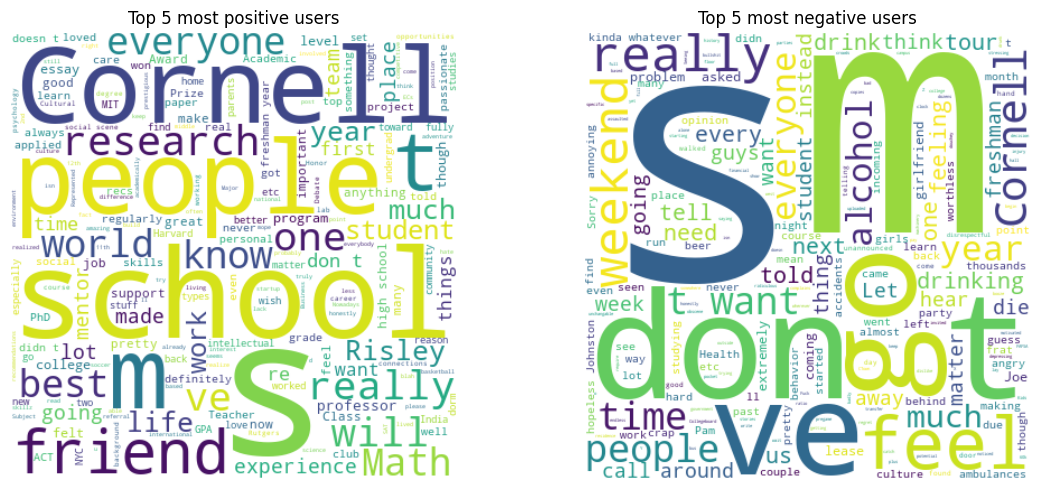

Top 5 by sentiment: ['phdtrek', 'cornellthrowaway0000', 'iamacoolpotato', 'heroesofmittens', 'hemanbc']
Bottom 5 by sentiment: ['Nanukana', 'MaybeImJustSad', 'NathanieltheYoung', 'NegativeBaby', 'Ultraballer2000']


In [23]:
# Global top/bottom users by mean sentiment
sorted_users = speaker_sent.sort_values("mean_compound", ascending=False)

top_users = list(sorted_users["speaker"].head(5))
bot_users = list(sorted_users["speaker"].tail(5))

top_text = " ".join(speaker_texts.get(u, "") for u in top_users)
bot_text = " ".join(speaker_texts.get(u, "") for u in bot_users)

def clean_text(text):
    # Very light cleaning; extend if you like
    text = re.sub(r"https?://\\S+", " ", text)  # remove URLs
    text = re.sub(r"[^A-Za-z0-9\\s]", " ", text)
    return text

top_text = clean_text(top_text)
bot_text = clean_text(bot_text)

plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
wc_top = WordCloud(width=400, height=400, background_color="white").generate(top_text)
plt.imshow(wc_top, interpolation="bilinear")
plt.axis("off")
plt.title("Top 5 most positive users")

plt.subplot(1, 2, 2)
wc_bot = WordCloud(width=400, height=400, background_color="white").generate(bot_text)
plt.imshow(wc_bot, interpolation="bilinear")
plt.axis("off")
plt.title("Top 5 most negative users")

plt.tight_layout()
plt.show()

print("Top 5 by sentiment:", top_users)
print("Bottom 5 by sentiment:", bot_users)


mean_compound    1.000000
betweenness     -0.016807
pagerank        -0.018559
in_degree       -0.022288
out_degree      -0.023229
core_number     -0.034786
Name: mean_compound, dtype: float64


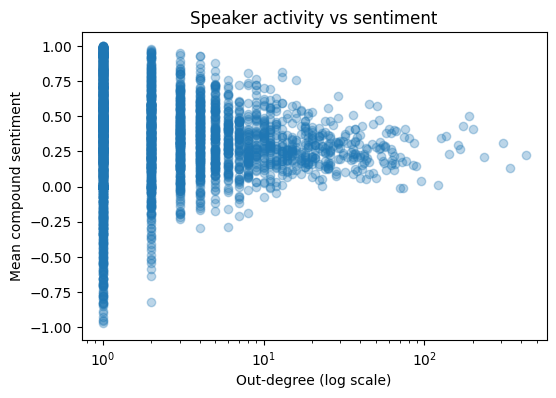

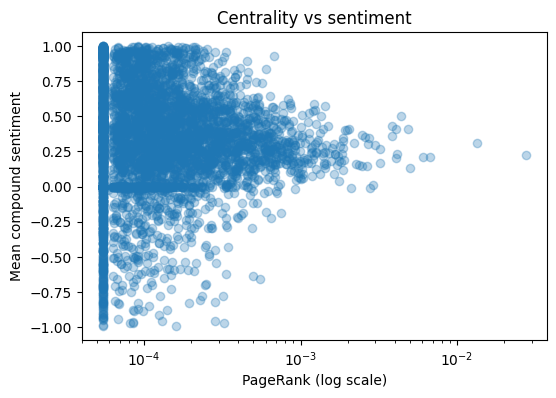

In [24]:
# Correlations between centrality and sentiment
corr_cols = ["in_degree", "out_degree", "betweenness", "pagerank",
             "core_number", "mean_compound"]
print(df_speaker[corr_cols].corr()["mean_compound"].sort_values(ascending=False))

# Scatter: out-degree vs sentiment
plt.figure(figsize=(6,4))
plt.scatter(df_speaker["out_degree"], df_speaker["mean_compound"], alpha=0.3)
plt.xscale("log")
plt.xlabel("Out-degree (log scale)")
plt.ylabel("Mean compound sentiment")
plt.title("Speaker activity vs sentiment")
plt.show()

# Scatter: PageRank vs sentiment
plt.figure(figsize=(6,4))
plt.scatter(df_speaker["pagerank"], df_speaker["mean_compound"], alpha=0.3)
plt.xscale("log")
plt.xlabel("PageRank (log scale)")
plt.ylabel("Mean compound sentiment")
plt.title("Centrality vs sentiment")
plt.show()